In [2]:
from quantum_function import *

# Entanglement of a pair of quantum emitters via continuous fluorescence measurements: a tutorial

### MCSOLVE - Photocounting, Chap.4

In [21]:
gamma = 10E6              # Atom decay rate
T_1 = 1 / gamma  # time constant for the decay

times = np.array(np.arange(0, 5*T_1, 0.001*T_1)) # time vector

#Initial states - have to use (2,2) states
my_initial_states = [ee, psi_plus, phi_plus]
my_name_states = ["ee", "psi_plus", "phi_plus"]
labels = [r"$|ee\rangle\rangle$", r"$|\psi^+\rangle\rangle$", r"$|\phi^+\rangle\rangle$"]

#Creo dict di dataframe per ogni stato iniziale
photodetection_dfs = {}
for name_state in my_name_states:
    photodetection_dfs[f"{name_state}"] = pd.DataFrame()

theo_curves = [
    2 * np.exp(-gamma * times)*(1-np.exp(-gamma * times)),
    np.exp(-gamma * times),
    np.exp(-gamma * times)*(2-np.exp(-gamma * times))
]

sigma_z_1 = tensor(sigmaz(), qeye(2))
sigma_z_2 = tensor(qeye(2), sigmaz())

ntraj = 100 # number of trajectories


# solve the master equation using montecarlo equation (photodetection) for every intial state
for name_state,state in zip(my_name_states, my_initial_states):
    my_photodetection = smesolve(
        H_free, state, times,
        c_ops = [
        np.sqrt(gamma / 2) * (sigma_z_1 + sigma_z_2),
        np.sqrt(gamma / 2) * (sigma_z_1 - sigma_z_2)
        ],

        sc_ops=[
        np.sqrt(gamma / 2) * (sigma_z_1 + sigma_z_2),
        np.sqrt(gamma / 2) * (sigma_z_1 - sigma_z_2)
        ],
        e_ops=[concurrence_for_solver_pure],
        ntraj=ntraj,
        options={"keep_runs_results": True}, #Necessary to create the keep the e_ops results for each trajectory
    )

    photodetection_dfs[f"{name_state}"] = pd.DataFrame(my_photodetection.expect[0].T, columns=[f"Traj_{i+1}" for i in range(ntraj)])
    photodetection_dfs[f"{name_state}"].index = np.arange(1, photodetection_dfs[f"{name_state}"].shape[0]+1)
    photodetection_dfs[f"{name_state}"].index.name = "Step"
    photodetection_dfs[f"{name_state}"]['mean'] = photodetection_dfs[f"{name_state}"].mean(axis=1)


c:\Users\campa\OneDrive\Desktop\Master Thesis\Stochastic_Master_Thesis\Codes\SMT_venv\Lib\site-packages\qutip\solver\sode\sode.py:160: RuntimeWarning: Step under minimum step (0.001), skipped.
  warnings.warn(


10.0%. Run time:   1.84s. Est. time left: 00:00:00:16
20.0%. Run time:   3.65s. Est. time left: 00:00:00:14
30.0%. Run time:   5.40s. Est. time left: 00:00:00:12
40.0%. Run time:   7.15s. Est. time left: 00:00:00:10
50.0%. Run time:   8.91s. Est. time left: 00:00:00:08
60.0%. Run time:  10.58s. Est. time left: 00:00:00:07
70.0%. Run time:  12.30s. Est. time left: 00:00:00:05
80.0%. Run time:  14.02s. Est. time left: 00:00:00:03
90.0%. Run time:  15.67s. Est. time left: 00:00:00:01
100.0%. Run time:  17.29s. Est. time left: 00:00:00:00
Total run time:  17.47s


c:\Users\campa\OneDrive\Desktop\Master Thesis\Stochastic_Master_Thesis\Codes\SMT_venv\Lib\site-packages\qutip\solver\sode\sode.py:160: RuntimeWarning: Step under minimum step (0.001), skipped.
  warnings.warn(


10.0%. Run time:   1.55s. Est. time left: 00:00:00:13
20.0%. Run time:   3.15s. Est. time left: 00:00:00:12
30.0%. Run time:   4.76s. Est. time left: 00:00:00:11
40.0%. Run time:   6.46s. Est. time left: 00:00:00:09
50.0%. Run time:   8.08s. Est. time left: 00:00:00:08
60.0%. Run time:   9.82s. Est. time left: 00:00:00:06
70.0%. Run time:  11.61s. Est. time left: 00:00:00:04
80.0%. Run time:  13.28s. Est. time left: 00:00:00:03
90.0%. Run time:  14.97s. Est. time left: 00:00:00:01
100.0%. Run time:  16.68s. Est. time left: 00:00:00:00
Total run time:  16.86s


c:\Users\campa\OneDrive\Desktop\Master Thesis\Stochastic_Master_Thesis\Codes\SMT_venv\Lib\site-packages\qutip\solver\sode\sode.py:160: RuntimeWarning: Step under minimum step (0.001), skipped.
  warnings.warn(


10.0%. Run time:   1.55s. Est. time left: 00:00:00:13
20.0%. Run time:   3.32s. Est. time left: 00:00:00:13
30.0%. Run time:   5.57s. Est. time left: 00:00:00:12
40.0%. Run time:   8.20s. Est. time left: 00:00:00:12
50.0%. Run time:  10.02s. Est. time left: 00:00:00:10
60.0%. Run time:  11.75s. Est. time left: 00:00:00:07
70.0%. Run time:  13.50s. Est. time left: 00:00:00:05
80.0%. Run time:  15.20s. Est. time left: 00:00:00:03
90.0%. Run time:  16.95s. Est. time left: 00:00:00:01
100.0%. Run time:  18.66s. Est. time left: 00:00:00:00
Total run time:  18.84s


In [22]:
photodetection_dfs["psi_plus"]

,Traj_1,Traj_2,Traj_3,Traj_4,Traj_5,Traj_6,Traj_7,Traj_8,Traj_9,Traj_10,...,Traj_92,Traj_93,Traj_94,Traj_95,Traj_96,Traj_97,Traj_98,Traj_99,Traj_100,mean
Step,,,,,,,,,,,,,,,,,,,,,
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4996,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4997,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4998,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


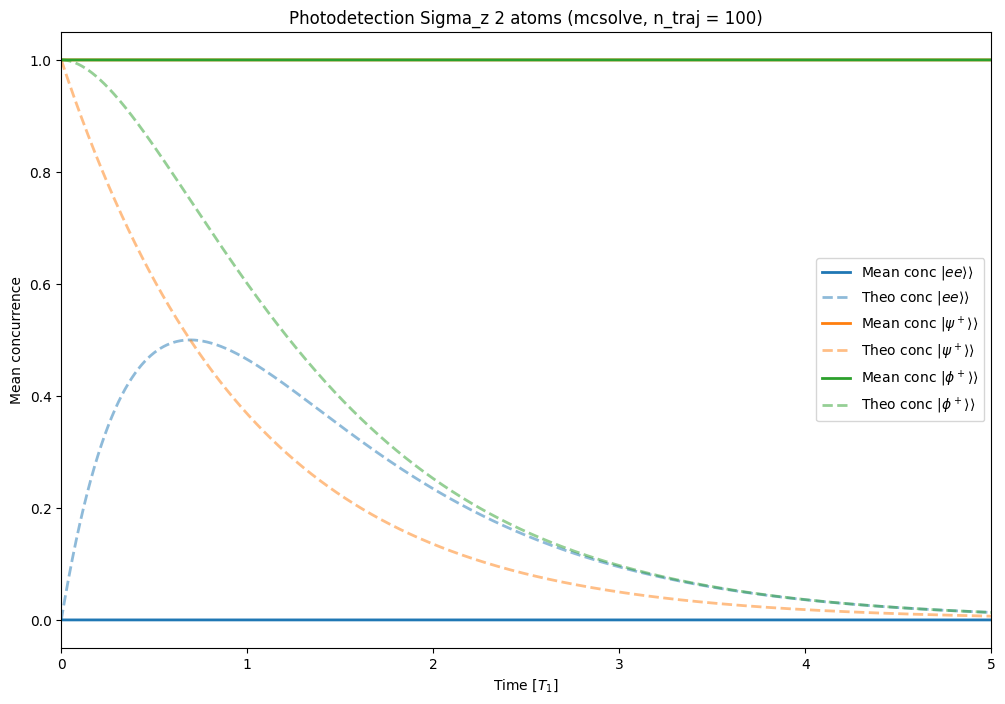

In [19]:
plt.figure(figsize=(12,8))

for state,theory,label in zip(my_name_states,theo_curves,labels):
    line_sim, = plt.plot(times/T_1, photodetection_dfs[f"{state}"]['mean'], label=f"Mean conc {label}", linewidth=2)
    plt.plot(times/T_1, theory, '--', label=f"Theo conc {label}", color=line_sim.get_color(), alpha=0.5, linewidth=2)

plt.xlim(0, 5)
plt.xlabel(r"Time [$T_1$]")
plt.ylabel("Mean concurrence")
plt.title(f"Photodetection Sigma_z 2 atoms (mcsolve, n_traj = {ntraj})")
plt.legend()
plt.show()